In [1]:
gen_report = False

In [2]:
import os
import json
import pandas as pd

root = "experiments"

records = []

for dirpath, dirnames, filenames in os.walk(root):
    if "report.json" in filenames:
        report_path = os.path.join(dirpath, "report.json")

        with open(report_path, "r") as f:
            data = json.load(f)

        record = {}

        record["VQEL"] = data.get("VQEL")

        # metrics
        for k, v in data.get("metrics", {}).items():
            record[k] = v

        # config
        for k, v in data.get("config", {}).items():
            if 'dir' in k.lower() or 'split' in k.lower():
                continue
            record[k] = v

        record["path"] = dirpath.replace('experiments/', '').replace('/results', '')
        records.append(record)

df = pd.DataFrame(records)

df["reset_unfrozen_params"] = df["reset_unfrozen_params"].map({True: "yes", False: "no"})
df["freeze_codebook"] = df["freeze_codebook"].map({True: "yes", False: "no"})
df["freeze_object_encoder"] = df["freeze_object_encoder"].map({True: "yes", False: "no"})

df.loc[df["num_iterations"] == 0, "learning_rate_tt"] = "-"
df.loc[df["agent_a_training_mode"] == 'frozen', "learning_rate_phase2_a"] = "-"
df.loc[df["best_of_n"].isna(), "best_of_n"] = 1
df.loc[df["dataset_tt"].isna(), "dataset_tt"] = "one_shape"
df.loc[df["sampling_temperature_tt"].isna(), "sampling_temperature_tt"] = df["sampling_temperature"]

df.loc[(df["num_iterations"] == 0) | (df["best_of_n"] == 1), "test_time_mode"] = "-"

df.rename(columns={"test_time_training_accuracy": "test_time_mutual_accuracy"}, inplace=True)
df.rename(columns={"test_time_self_play_accuracy": "test_time_self_accuracy"}, inplace=True)

df["test_time_mode"] = df["test_time_mode"].replace("adaptation", "sample_adaptation")
df["dataset"] = df["dataset"].replace("shape", "shape1")
df["dataset_tt"] = df["dataset_tt"].replace("two_shape", "shape2")
df["dataset_tt"] = df["dataset_tt"].replace("shape_unique_double_attribute", "dual_attribute_shape")
# df["dataset_tt"] = df["dataset_tt"].replace("shape_unique_double_attribute", "single_attribute_shape")

df.loc[df["baseline"].isna(), "baseline"] = False

df.loc[df["baseline"], "test_time_mode"] = "-"


df = df.where(pd.notna(df), "None")
pd.options.display.float_format = '{:.10g}'.format
df = df.map(lambda x: f"{x:.0e}" if isinstance(x, (int, float)) and x != 0 and (abs(x) < 0.01 or abs(x) == 0.1 or abs(x) == 0.01) else x)
print("Total reports loaded:", len(df))


Total reports loaded: 1459


/tmp/ipykernel_3770/2399659346.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["num_iterations"] == 0, "learning_rate_tt"] = "-"
/tmp/ipykernel_3770/2399659346.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["agent_a_training_mode"] == 'frozen', "learning_rate_phase2_a"] = "-"


In [3]:
def filter_df(filters, df=df, sort_by=["message_length", "message_length_tt", "learning_rate_tt", "num_iterations"]):

    idx = pd.Series(True, index=df.index)

    for key, values in filters.items():
        mask = pd.Series(False, index=df.index)
        if not isinstance(values, (list, tuple, set)):
            values = [values]
        for value in values:
            if value == "!None":
                mask |= (df[key] != "None")
            else:
                mask |= (df[key] == value)
        idx &= mask 

    return df[idx].sort_values(by=sort_by).reset_index(drop=True)

    

In [4]:
import base64

def to_html(df):    

    # ---- highlight rule ----
    # if 'mutual_play_accuracy' in df:
    #     max_col = 'mutual_play_accuracy'
    # else:
    #     max_col = 'test_accuracy'
    # max_val = pd.to_numeric(df[max_col]).max()

    # def highlight_max_row(row):
    #     if  pd.to_numeric(row[max_col]) == max_val:
    #         return ['font-weight: bold; background-color: #ffff99'] * len(row)
    #     else:
    #         return [''] * len(row)

    # ---- style ----
    styled = (
        df.style
            # .apply(highlight_max_row, axis=1)  # <<< APPLY HIGHLIGHT HERE
            .hide(axis="index")
            .format(
                lambda x: (
                    f"{int(x)}"                      # 20.0 -> 20
                    if isinstance(x, float) and x.is_integer()
                    else f"{x:.0e}"                  # small numbers -> scientific
                    if isinstance(x, (int, float)) and x != 0 and abs(x) < 0.01
                    else x
                )
            )
            .set_table_styles([
                {"selector": "td", "props": [("border-right", "1px solid black")]},
                {"selector": "th", "props": [
                    ("border-right", "1px solid black"),
                    ("color", "darkblue"),
                    ("font-weight", "bold"),
                    ("padding-left", "8px"),
                    ("padding-right", "8px")
                ]},
            ])
            .set_properties(**{"text-align": "center"})
    )

    html_table = styled.to_html(index=False)

    if gen_report:
        with open("results.html", "a") as f:
            f.write(html_table)

        
def add_heading(num=1, title=""):
    """Add a professional-colored heading to results.html"""
    colors = ["#0b3d91",  # dark blue
              "#800000",  # maroon
              "#205522",  # dark green
              "#111011",  # indigo
              "#444444"]  # dark gray
    color = colors[(num-1) % len(colors)]  # cycle through colors
    
    if gen_report:
        with open("results.html", "a") as f:
            f.write(f'<h{num} style="color:{color}; font-family:Arial, sans-serif;">{title}</h{num}>\n')
        
def clear():
    if gen_report:
        with open("results.html", "w") as f:
            f.write("")

def line():
    if gen_report:
        with open("results.html", "a") as f:
            f.write('<hr style="border:1px solid #444; margin:10px 0;">\n')
        
        
def write(text):
    html_text = text.replace("\n", "<br>\n")
    
    if gen_report:
        with open("results.html", "a") as f:
            f.write(f"{html_text}\n")


def add_plot(path="plot.png"):
    """Embed an image file directly into results.html using base64."""
    with open(path, "rb") as img:
        encoded = base64.b64encode(img.read()).decode("utf-8")

    html_img = (
        '<img src="data:image/png;base64,' +
        encoded +
        '" style="max-width:650px; height:auto;"><br>\n'
    )

    if gen_report:
        with open("results.html", "a") as f:
            f.write(html_img)
        
    if os.path.exists(path):
        os.remove(path)

In [5]:
import os
import shutil

def remove_expr(res_df):
    for path in res_df["path"]:
        full_path = os.path.join("experiments", path)

        if not os.path.isdir(full_path):
            print(f"[SKIP] Not found: {full_path}")
            continue

        answer = input(f"⚠️ Delete expr '{path}' ? (y/n): ").strip().lower()

        if answer == "y":
            shutil.rmtree(full_path)
            print(f"✅ Deleted: {path}")
        else:
            print(f"❌ Skipped: {path}")

In [6]:
from itertools import product
import pandas as pd


def extract_maxes(df, cols=["message_length", "message_length_tt", "seed"], max_col="test_time_mutual_accuracy"):
    values = []
    for col in cols:
        value = set(df[col])
        values.append(value)

    combinations = [list(x) for x in product(*values)]

    maxes = []
    for comb in combinations:
        section = filter_df({col: value for col, value in zip(cols, comb)}, df)
        if not section.empty:
            max_row = section.loc[pd.to_numeric(section[max_col]).idxmax()]
            maxes.append(max_row.to_frame().T)

    final_df = pd.concat(maxes, ignore_index=True)
    return final_df.sort_values(by=cols)


def mean_and_std(df, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode"], metrics=["test_time_self_accuracy", "test_time_mutual_accuracy"]):
    rows = []

    for i in range(0, len(df), 3):
        chunk = df.iloc[i:i+3]
        
        rows.append(
            {col: chunk[col].iloc[0] for col in config_cols} | 
            {metric: f"{pd.to_numeric(chunk[metric]).mean() * 100:.1f} ± {pd.to_numeric(chunk[metric]).std() * 100:.1f}" for metric in metrics}
        )

    out = pd.DataFrame(rows)
    return out.sort_values(by=config_cols)
    

In [7]:
import matplotlib.pyplot as plt

def plot(df1, df2, df3, labels=("Baseline", "VQ-NoTT", "Adaptation")):
    plt.figure(figsize=(6, 4))

    for df, label in zip((df1, df2, df3), labels):
        df = df.copy()

        # Split "mean ± std"
        df[["mean_acc", "std_acc"]] = (
            df["test_time_mutual_accuracy"]
            .str.split("±", expand=True)
            .astype(float)
        )
        df = df.sort_values("message_length_tt")

        x = df["message_length_tt"]
        y = df["mean_acc"]
        err = df["std_acc"]

        plt.plot(x, y, label=label)
        plt.fill_between(x, y - err, y + err, alpha=0.25)

    plt.xlabel("Message Length", fontsize=12)
    plt.ylabel("Test-Time Mutual Accuracy (%)", fontsize=12)
    plt.title("Accuracy vs. Message Length", fontsize=13)
    plt.xticks(x)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
clear()

---

In [9]:
backbone_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "learning_rate_phase1", 
    "learning_rate_phase2_a", 
    "learning_rate_phase2_b",
    "test_time_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
    "path",
]

backbone_cols_report = [
    "seed",
    "message_length",
    "agent_a_training_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
]

baseline_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

baseline_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

scaling_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "sampling_temperature_tt",
    "best_of_n",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

scaling_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "sampling_temperature_tt",
    "best_of_n",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

adapt_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

adapt_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

In [10]:
write(
"""
- <b>Shape1</b>: Contains only one shape.

- <b>Shape2</b>: Contains exactly two shapes.

- <b>Shape12</b>: Contains one or two shapes.

- <b>MNIST1</b>: Contains one digit on either the left or right side of the image (the other side is empty).

- <b>MNIST2</b>: Contains two digits.

- <b>ImageNet_same_class</b>: Distractors and targets belong to the same class.

- <b>Single Attribute Shape</b>: Candidates in a batch have two attributes; the value of one attribute is different for all images,
while there is no restriction on the value of the other attribute—it may be the same for some images and different for others.

- <b>Dual-attribute shape</b>: Candidates in a batch have two attributes, and all candidates can be distinguished from one another 
if and only if the values of both attributes are described.
"""
)

# Shape1

## Baseline

In [11]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "None",
    "baseline": True,
}, sort_by=["seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,shape1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.863,20251230_1445_bs32_vocab10_repr1024_msg_len4_l...
1,2,True,shape1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.865,20251230_1503_bs32_vocab10_repr1024_msg_len4_l...
2,3,True,shape1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.867,20251230_1518_bs32_vocab10_repr1024_msg_len4_l...


In [12]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,shape1,"[3, 4]",86.5 ± 0.2


In [13]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "!None",
    "baseline": True,
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [14]:
baseline = mean_and_std(res)
baseline

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape1,"[3, 4]",4,shape2,-,0.0 ± 0.0,45.5 ± 2.9
1,shape1,"[3, 4]",5,shape2,-,0.0 ± 0.0,46.5 ± 3.0
2,shape1,"[3, 4]",6,shape2,-,0.0 ± 0.0,44.9 ± 3.5
3,shape1,"[3, 4]",7,shape2,-,0.0 ± 0.0,40.6 ± 5.6
4,shape1,"[3, 4]",8,shape2,-,0.0 ± 0.0,35.2 ± 7.1
5,shape1,"[3, 4]",9,shape2,-,0.0 ± 0.0,30.5 ± 9.5
6,shape1,"[3, 4]",10,shape2,-,0.0 ± 0.0,26.6 ± 10.3
7,shape1,"[3, 4]",11,shape2,-,0.0 ± 0.0,23.3 ± 10.5
8,shape1,"[3, 4]",12,shape2,-,0.0 ± 0.0,20.8 ± 10.2
9,shape1,"[3, 4]",13,shape2,-,0.0 ± 0.0,18.7 ± 10.0


## Backbone

In [15]:
add_heading(2, "Shape1")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-",
    "dialogued_checkpoint": "None",
}, sort_by=["message_length"])
res = extract_maxes(res, max_col="mutual_play_accuracy")

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
2,1,False,shape1,cosine,"[3, 4]",1e-03,-,1e-04,-,0.841,0.889,20251220_0615_bs32_vocab10_repr1024_lr1_0.001_...
0,2,False,shape1,cosine,"[3, 4]",1e-03,-,1e-03,-,0.837,0.888,20251228_1437_bs32_vocab10_repr1024_msg_len10_...
1,3,False,shape1,cosine,"[3, 4]",1e-03,-,1e-04,-,0.846,0.885,20251228_2016_bs32_vocab10_repr1024_msg_len10_...


In [16]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,shape1,"[3, 4]",84.1 ± 0.5,88.7 ± 0.2


## VQ-NoTT

In [17]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dataset_tt": "shape2",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-"
}, sort_by=["message_length_tt", "seed"])

to_html(res[baseline_cols_report])

# res[baseline_cols]

In [18]:
VQ_NoTT = mean_and_std(res)
VQ_NoTT

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape1,"[3, 4]",4,shape2,-,41.2 ± 2.5,47.9 ± 1.1
1,shape1,"[3, 4]",5,shape2,-,43.6 ± 2.2,49.6 ± 2.0
2,shape1,"[3, 4]",6,shape2,-,44.1 ± 2.2,50.1 ± 2.2
3,shape1,"[3, 4]",7,shape2,-,44.1 ± 2.9,48.8 ± 3.5
4,shape1,"[3, 4]",8,shape2,-,43.9 ± 2.5,47.6 ± 4.5
5,shape1,"[3, 4]",9,shape2,-,43.3 ± 2.4,46.7 ± 5.1
6,shape1,"[3, 4]",10,shape2,-,42.7 ± 3.4,44.7 ± 5.5
7,shape1,"[3, 4]",11,shape2,-,42.2 ± 2.9,43.8 ± 6.6
8,shape1,"[3, 4]",12,shape2,-,41.1 ± 3.9,42.6 ± 6.9
9,shape1,"[3, 4]",13,shape2,-,40.2 ± 3.4,40.7 ± 7.3


## Scaling

In [19]:
add_heading(3, "Scaling")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": "scaling"
}, sort_by=["message_length", "message_length_tt", "seed", "sampling_temperature_tt", "best_of_n"])

to_html(res[scaling_cols_report])

res[scaling_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,sampling_temperature_tt,best_of_n,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,shape1,cosine,"[3, 4]",4,shape2,scaling,1e-02,50,0.4,0.47,20251230_2307_bs32_vocab10_repr1024_msg_len4_l...
1,1,False,shape1,cosine,"[3, 4]",4,shape2,scaling,1e-02,50,0.4,0.47,20251228_0136_bs32_vocab10_repr1024_msg_len4_l...
2,2,False,shape1,cosine,"[3, 4]",4,shape2,scaling,1e-02,50,0.429,0.5,20251231_0154_bs32_vocab10_repr1024_msg_len4_l...
3,3,False,shape1,cosine,"[3, 4]",4,shape2,scaling,1e-02,50,0.451,0.499,20251231_0442_bs32_vocab10_repr1024_msg_len4_l...
4,1,False,shape1,cosine,"[3, 4]",5,shape2,scaling,1e-01,10,0.437,0.494,20251223_0017_bs32_vocab10_repr1024_lr1_0.001_...
5,1,False,shape1,cosine,"[3, 4]",5,shape2,scaling,1e-01,20,0.442,0.479,20251223_0021_bs32_vocab10_repr1024_lr1_0.001_...
6,1,False,shape1,cosine,"[3, 4]",5,shape2,scaling,1e-02,50,0.432,0.487,20251230_2326_bs32_vocab10_repr1024_msg_len5_l...
7,1,False,shape1,cosine,"[3, 4]",5,shape2,scaling,1e-02,50,0.432,0.487,20251227_2316_bs32_vocab10_repr1024_msg_len5_l...
8,2,False,shape1,cosine,"[3, 4]",5,shape2,scaling,1e-02,50,0.447,0.512,20251231_0213_bs32_vocab10_repr1024_msg_len5_l...
9,3,False,shape1,cosine,"[3, 4]",5,shape2,scaling,1e-02,50,0.477,0.513,20251231_0501_bs32_vocab10_repr1024_msg_len5_l...


In [20]:
final = extract_maxes(res)
final[scaling_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,sampling_temperature_tt,best_of_n,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,shape1,cosine,"[3, 4]",4,shape2,scaling,1e-02,50,0.4,0.47,20251230_2307_bs32_vocab10_repr1024_msg_len4_l...
1,2,False,shape1,cosine,"[3, 4]",4,shape2,scaling,1e-02,50,0.429,0.5,20251231_0154_bs32_vocab10_repr1024_msg_len4_l...
2,3,False,shape1,cosine,"[3, 4]",4,shape2,scaling,1e-02,50,0.451,0.499,20251231_0442_bs32_vocab10_repr1024_msg_len4_l...
3,1,False,shape1,cosine,"[3, 4]",5,shape2,scaling,1e-01,10,0.437,0.494,20251223_0017_bs32_vocab10_repr1024_lr1_0.001_...
4,2,False,shape1,cosine,"[3, 4]",5,shape2,scaling,1e-02,50,0.447,0.512,20251231_0213_bs32_vocab10_repr1024_msg_len5_l...
5,3,False,shape1,cosine,"[3, 4]",5,shape2,scaling,1e-02,50,0.477,0.513,20251231_0501_bs32_vocab10_repr1024_msg_len5_l...
6,1,False,shape1,cosine,"[3, 4]",6,shape2,scaling,1e-02,50,0.431,0.488,20251227_2339_bs32_vocab10_repr1024_msg_len6_l...
7,2,False,shape1,cosine,"[3, 4]",6,shape2,scaling,1e-02,50,0.46,0.515,20251231_0235_bs32_vocab10_repr1024_msg_len6_l...
8,3,False,shape1,cosine,"[3, 4]",6,shape2,scaling,1e-02,50,0.473,0.523,20251231_0524_bs32_vocab10_repr1024_msg_len6_l...
9,1,False,shape1,cosine,"[3, 4]",7,shape2,scaling,1e-02,50,0.432,0.468,20251228_0003_bs32_vocab10_repr1024_msg_len7_l...


In [21]:
scaling = mean_and_std(final)
scaling

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape1,"[3, 4]",4,shape2,scaling,42.7 ± 2.6,49.0 ± 1.7
1,shape1,"[3, 4]",5,shape2,scaling,45.4 ± 2.1,50.6 ± 1.1
2,shape1,"[3, 4]",6,shape2,scaling,45.5 ± 2.2,50.9 ± 1.8
3,shape1,"[3, 4]",7,shape2,scaling,45.4 ± 2.3,50.2 ± 2.9
4,shape1,"[3, 4]",8,shape2,scaling,45.7 ± 2.4,49.0 ± 2.8
5,shape1,"[3, 4]",9,shape2,scaling,45.1 ± 3.0,48.2 ± 3.8


## Adaptation

In [22]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": ["batch_adaptation"],
}, sort_by=["message_length_tt","seed", "learning_rate_tt"])

to_html(res[adapt_cols_report])

# res[adapt_cols]

In [23]:
final = extract_maxes(res)
# final[adapt_cols]

In [24]:
adapt = mean_and_std(final)
to_html(adapt)
adapt

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape1,"[3, 4]",4,shape2,batch_adaptation,48.1 ± 3.5,53.4 ± 2.1
1,shape1,"[3, 4]",5,shape2,batch_adaptation,52.0 ± 4.0,55.1 ± 2.1
2,shape1,"[3, 4]",6,shape2,batch_adaptation,53.8 ± 4.8,55.6 ± 2.7
3,shape1,"[3, 4]",7,shape2,batch_adaptation,56.2 ± 4.0,56.4 ± 2.5
4,shape1,"[3, 4]",8,shape2,batch_adaptation,55.9 ± 4.7,56.3 ± 2.7
5,shape1,"[3, 4]",9,shape2,batch_adaptation,57.1 ± 2.8,56.3 ± 2.1
6,shape1,"[3, 4]",10,shape2,batch_adaptation,57.3 ± 4.0,55.9 ± 2.7
7,shape1,"[3, 4]",11,shape2,batch_adaptation,57.7 ± 4.7,55.2 ± 3.3
8,shape1,"[3, 4]",12,shape2,batch_adaptation,58.7 ± 3.9,56.3 ± 2.7
9,shape1,"[3, 4]",13,shape2,batch_adaptation,58.4 ± 4.0,55.6 ± 3.0


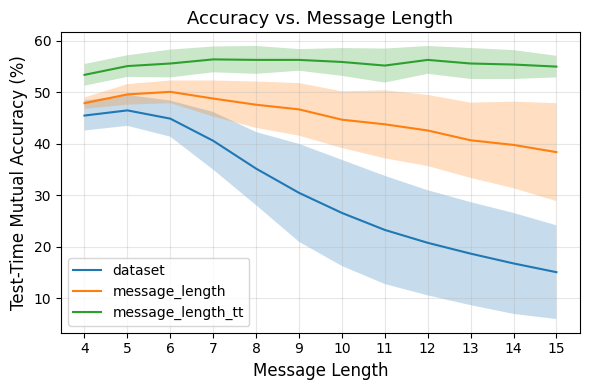

In [25]:
plot(baseline, VQ_NoTT, adapt, scaling)

# Shape12

## Baseline

In [26]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape12",
    "baseline": True,
    "dialogued_checkpoint": "None"
}, sort_by=["seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,shape12,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.861,20251230_1916_bs32_vocab10_repr1024_msg_len4_l...
1,2,True,shape12,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.886,20251230_1932_bs32_vocab10_repr1024_msg_len4_l...
2,3,True,shape12,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.867,20251230_1947_bs32_vocab10_repr1024_msg_len4_l...


In [27]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,shape12,"[3, 4]",87.1 ± 1.3


In [28]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape12",
    "baseline": True,
    "dialogued_checkpoint": "!None"
}, sort_by=["message_length_tt", "seed"])

res[baseline_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,True,shape12,cosine,"[3, 4]",4,shape3,-,0,0.793,20251230_2041_bs32_vocab10_repr1024_msg_len4_l...
1,2,True,shape12,cosine,"[3, 4]",4,shape3,-,0,0.812,20251230_2044_bs32_vocab10_repr1024_msg_len4_l...
2,3,True,shape12,cosine,"[3, 4]",4,shape3,-,0,0.77,20251230_2046_bs32_vocab10_repr1024_msg_len4_l...
3,1,True,shape12,cosine,"[3, 4]",5,shape3,-,0,0.851,20251230_2042_bs32_vocab10_repr1024_msg_len5_l...
4,2,True,shape12,cosine,"[3, 4]",5,shape3,-,0,0.879,20251230_2044_bs32_vocab10_repr1024_msg_len5_l...
5,3,True,shape12,cosine,"[3, 4]",5,shape3,-,0,0.821,20251230_2046_bs32_vocab10_repr1024_msg_len5_l...
6,1,True,shape12,cosine,"[3, 4]",6,shape3,-,0,0.86,20251230_2042_bs32_vocab10_repr1024_msg_len6_l...
7,2,True,shape12,cosine,"[3, 4]",6,shape3,-,0,0.87,20251230_2044_bs32_vocab10_repr1024_msg_len6_l...
8,3,True,shape12,cosine,"[3, 4]",6,shape3,-,0,0.805,20251230_2047_bs32_vocab10_repr1024_msg_len6_l...
9,1,True,shape12,cosine,"[3, 4]",7,shape3,-,0,0.798,20251230_2042_bs32_vocab10_repr1024_msg_len7_l...


In [29]:
baseline = mean_and_std(res)
baseline

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape12,"[3, 4]",4,shape3,-,0.0 ± 0.0,79.2 ± 2.1
1,shape12,"[3, 4]",5,shape3,-,0.0 ± 0.0,85.0 ± 2.9
2,shape12,"[3, 4]",6,shape3,-,0.0 ± 0.0,84.5 ± 3.5
3,shape12,"[3, 4]",7,shape3,-,0.0 ± 0.0,77.6 ± 4.8
4,shape12,"[3, 4]",8,shape3,-,0.0 ± 0.0,67.4 ± 4.4
5,shape12,"[3, 4]",9,shape3,-,0.0 ± 0.0,56.2 ± 3.8
6,shape12,"[3, 4]",10,shape3,-,0.0 ± 0.0,46.4 ± 3.1
7,shape12,"[3, 4]",11,shape3,-,0.0 ± 0.0,38.5 ± 3.1
8,shape12,"[3, 4]",12,shape3,-,0.0 ± 0.0,31.9 ± 3.6
9,shape12,"[3, 4]",13,shape3,-,0.0 ± 0.0,26.8 ± 3.4


## Backbone

In [30]:
add_heading(2, "Shape12")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "shape12",
    "sim": "cosine",
    "baseline": False,
    "dialogued_checkpoint": "None",
}, sort_by=["seed", "message_length"])

to_html(res[backbone_cols_report])

# res[backbone_cols]

In [31]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,shape12,"[3, 4]",77.2 ± 0.4,86.5 ± 0.8


## VQ-NoTT

In [32]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape12",
    "sim": "cosine",
    "dataset_tt": "shape3",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-"
}, sort_by=["message_length_tt", "seed"])

to_html(res[baseline_cols_report])

res[baseline_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,shape12,cosine,"[3, 4]",4,shape3,-,0.59,0.664,20251225_2040_bs32_vocab10_repr1024_lr1_0.0001...
1,2,False,shape12,cosine,"[3, 4]",4,shape3,-,0.574,0.652,20251228_2033_bs32_vocab10_repr1024_msg_len4_l...
2,3,False,shape12,cosine,"[3, 4]",4,shape3,-,0.629,0.649,20251228_2039_bs32_vocab10_repr1024_msg_len4_l...
3,1,False,shape12,cosine,"[3, 4]",5,shape3,-,0.65,0.732,20251225_2050_bs32_vocab10_repr1024_lr1_0.0001...
4,2,False,shape12,cosine,"[3, 4]",5,shape3,-,0.661,0.736,20251228_2033_bs32_vocab10_repr1024_msg_len5_l...
5,3,False,shape12,cosine,"[3, 4]",5,shape3,-,0.707,0.728,20251228_2040_bs32_vocab10_repr1024_msg_len5_l...
6,1,False,shape12,cosine,"[3, 4]",6,shape3,-,0.616,0.737,20251225_2052_bs32_vocab10_repr1024_lr1_0.0001...
7,2,False,shape12,cosine,"[3, 4]",6,shape3,-,0.692,0.771,20251228_2034_bs32_vocab10_repr1024_msg_len6_l...
8,3,False,shape12,cosine,"[3, 4]",6,shape3,-,0.716,0.721,20251228_2040_bs32_vocab10_repr1024_msg_len6_l...
9,1,False,shape12,cosine,"[3, 4]",7,shape3,-,0.51,0.715,20251225_2054_bs32_vocab10_repr1024_lr1_0.0001...


In [33]:
VQ_NoTT = mean_and_std(res)
VQ_NoTT

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape12,"[3, 4]",4,shape3,-,59.8 ± 2.8,65.5 ± 0.8
1,shape12,"[3, 4]",5,shape3,-,67.3 ± 3.0,73.2 ± 0.4
2,shape12,"[3, 4]",6,shape3,-,67.5 ± 5.2,74.3 ± 2.6
3,shape12,"[3, 4]",7,shape3,-,61.3 ± 9.4,71.7 ± 2.1
4,shape12,"[3, 4]",8,shape3,-,50.2 ± 15.5,66.3 ± 2.6
5,shape12,"[3, 4]",9,shape3,-,39.0 ± 21.3,60.2 ± 1.2
6,shape12,"[3, 4]",10,shape3,-,30.6 ± 25.2,55.9 ± 1.4
7,shape12,"[3, 4]",11,shape3,-,27.0 ± 23.7,51.4 ± 1.2
8,shape12,"[3, 4]",12,shape3,-,25.7 ± 21.2,45.9 ± 2.2
9,shape12,"[3, 4]",13,shape3,-,25.7 ± 18.8,40.5 ± 2.1


## Scaling

In [34]:
add_heading(3, "Scaling")

res = filter_df({
    "dataset": "shape12",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": "scaling"
}, sort_by=["message_length", "message_length_tt", "sampling_temperature_tt", "best_of_n"])

to_html(res[scaling_cols_report])

# res[scaling_cols]

## Adaptation

In [35]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "shape12",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": ["batch_adaptation"],
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

res[adapt_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,shape12,cosine,"[3, 4]",4,shape3,batch_adaptation,1e-04,25,0.597,0.607,20251230_1247_bs32_vocab10_repr1024_msg_len4_l...
1,1,False,shape12,cosine,"[3, 4]",4,shape3,batch_adaptation,1e-04,50,0.64,0.64,20251230_1001_bs32_vocab10_repr1024_msg_len4_l...
2,1,False,shape12,cosine,"[3, 4]",4,shape3,batch_adaptation,1e-04,100,0.63,0.588,20251230_0052_bs32_vocab10_repr1024_msg_len4_l...
3,1,False,shape12,cosine,"[3, 4]",4,shape3,batch_adaptation,1e-04,200,0.567,0.507,20251225_1939_bs32_vocab10_repr1024_lr1_0.0001...
4,1,False,shape12,cosine,"[3, 4]",4,shape3,batch_adaptation,1e-05,200,0.661,0.684,20251227_0228_bs32_vocab10_repr1024_lr1_0.0001...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,2,False,shape12,cosine,"[3, 4]",15,shape3,batch_adaptation,1e-05,200,0.822,0.448,20251228_2151_bs32_vocab10_repr1024_msg_len15_...
150,3,False,shape12,cosine,"[3, 4]",15,shape3,batch_adaptation,1e-04,25,0.637,0.517,20251230_1309_bs32_vocab10_repr1024_msg_len15_...
151,3,False,shape12,cosine,"[3, 4]",15,shape3,batch_adaptation,1e-04,50,0.78,0.569,20251230_1036_bs32_vocab10_repr1024_msg_len15_...
152,3,False,shape12,cosine,"[3, 4]",15,shape3,batch_adaptation,1e-04,100,0.876,0.565,20251230_0155_bs32_vocab10_repr1024_msg_len15_...


In [36]:
final = extract_maxes(res)
final[adapt_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,shape12,cosine,"[3, 4]",4,shape3,batch_adaptation,1e-05,200,0.661,0.684,20251227_0228_bs32_vocab10_repr1024_lr1_0.0001...
1,2,False,shape12,cosine,"[3, 4]",4,shape3,batch_adaptation,1e-05,200,0.627,0.62,20251228_2116_bs32_vocab10_repr1024_msg_len4_l...
2,3,False,shape12,cosine,"[3, 4]",4,shape3,batch_adaptation,1e-05,200,0.667,0.655,20251228_2155_bs32_vocab10_repr1024_msg_len4_l...
3,1,False,shape12,cosine,"[3, 4]",5,shape3,batch_adaptation,1e-05,200,0.747,0.766,20251227_0230_bs32_vocab10_repr1024_lr1_0.0001...
4,2,False,shape12,cosine,"[3, 4]",5,shape3,batch_adaptation,1e-05,200,0.7,0.709,20251228_2118_bs32_vocab10_repr1024_msg_len5_l...
5,3,False,shape12,cosine,"[3, 4]",5,shape3,batch_adaptation,1e-05,200,0.741,0.735,20251228_2157_bs32_vocab10_repr1024_msg_len5_l...
6,1,False,shape12,cosine,"[3, 4]",6,shape3,batch_adaptation,1e-05,200,0.796,0.827,20251227_0233_bs32_vocab10_repr1024_lr1_0.0001...
7,2,False,shape12,cosine,"[3, 4]",6,shape3,batch_adaptation,1e-05,200,0.747,0.767,20251228_2121_bs32_vocab10_repr1024_msg_len6_l...
8,3,False,shape12,cosine,"[3, 4]",6,shape3,batch_adaptation,1e-05,200,0.784,0.77,20251228_2159_bs32_vocab10_repr1024_msg_len6_l...
9,1,False,shape12,cosine,"[3, 4]",7,shape3,batch_adaptation,1e-05,200,0.741,0.841,20251227_0235_bs32_vocab10_repr1024_lr1_0.0001...


In [37]:
adapt = mean_and_std(final)
# adapt

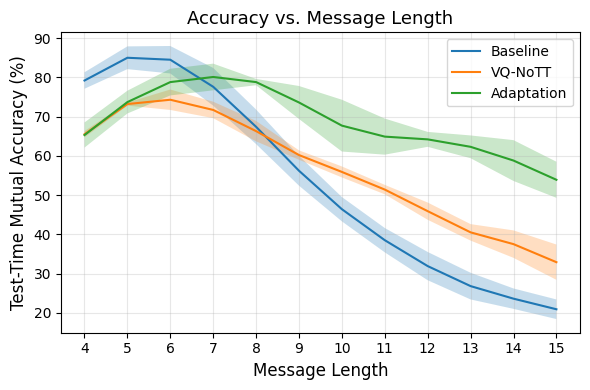

In [38]:
plot(baseline, VQ_NoTT, adapt)

# MNIST

## Baseline

In [39]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "None"
}, sort_by=["seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.925,20251230_1620_bs32_vocab10_repr192_msg_len4_lr...
1,2,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.858,20251230_1705_bs32_vocab10_repr192_msg_len4_lr...
2,3,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.882,20251230_1750_bs32_vocab10_repr192_msg_len4_lr...


In [40]:
mean_and_std(res)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist1,-,0.0 ± 0.0,86.9 ± 2.3


In [41]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "!None"
}, sort_by=["message_length_tt", "seed"])

# res[baseline_cols]

In [42]:
baseline = mean_and_std(res)
baseline

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist2,-,0.0 ± 0.0,25.7 ± 5.0
1,mnist1,"[3, 4]",5,mnist2,-,0.0 ± 0.0,25.7 ± 5.6
2,mnist1,"[3, 4]",6,mnist2,-,0.0 ± 0.0,24.0 ± 6.7
3,mnist1,"[3, 4]",7,mnist2,-,0.0 ± 0.0,21.4 ± 7.4
4,mnist1,"[3, 4]",8,mnist2,-,0.0 ± 0.0,18.6 ± 8.1
5,mnist1,"[3, 4]",9,mnist2,-,0.0 ± 0.0,16.0 ± 7.7
6,mnist1,"[3, 4]",10,mnist2,-,0.0 ± 0.0,14.2 ± 7.2
7,mnist1,"[3, 4]",11,mnist2,-,0.0 ± 0.0,12.8 ± 6.9
8,mnist1,"[3, 4]",12,mnist2,-,0.0 ± 0.0,11.6 ± 6.2
9,mnist1,"[3, 4]",13,mnist2,-,0.0 ± 0.0,10.4 ± 5.4


## Backbone

In [43]:
add_heading(2, "MNIST")
add_heading(3, 'Base Model')
res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": "[3, 4]",
}, sort_by=["message_length", "message_length_tt"])


res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0.788,0.895,20251223_1750_bs32_vocab10_repr192_lr1_0.0001_...
1,2,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0.787,0.891,20251228_1548_bs32_vocab10_repr192_msg_len10_l...
2,3,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0.799,0.918,20251228_1637_bs32_vocab10_repr192_msg_len10_l...


In [44]:
res.loc[0, 'path']

'20251223_1750_bs32_vocab10_repr192_lr1_0.0001_lr2a_0.0001_lr2b_0.0001_decay0.99_modefrozen_temp1e-05_ent0_cand100_contr0.01_seed1'

In [45]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,mnist1,"[3, 4]",79.1 ± 0.7,90.1 ± 1.5


## VQ-NoTT

In [46]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "-"
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [47]:
VQ_NoTT = mean_and_std(res)
to_html(VQ_NoTT)
VQ_NoTT

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist2,-,44.5 ± 3.9,42.0 ± 2.8
1,mnist1,"[3, 4]",5,mnist2,-,49.3 ± 4.2,46.0 ± 2.7
2,mnist1,"[3, 4]",6,mnist2,-,51.8 ± 4.7,48.5 ± 2.3
3,mnist1,"[3, 4]",7,mnist2,-,51.6 ± 3.9,49.0 ± 1.7
4,mnist1,"[3, 4]",8,mnist2,-,50.9 ± 3.6,48.1 ± 2.0
5,mnist1,"[3, 4]",9,mnist2,-,48.6 ± 3.5,46.1 ± 1.6
6,mnist1,"[3, 4]",10,mnist2,-,46.8 ± 3.8,43.0 ± 0.6
7,mnist1,"[3, 4]",11,mnist2,-,43.8 ± 3.8,39.2 ± 1.3
8,mnist1,"[3, 4]",12,mnist2,-,41.1 ± 4.2,35.3 ± 1.3
9,mnist1,"[3, 4]",13,mnist2,-,38.9 ± 5.7,33.8 ± 1.3


## Scaling

In [48]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "scaling"
}, sort_by=["message_length", "message_length_tt", "sampling_temperature_tt", "best_of_n"])

to_html(res[scaling_cols_report])

res[scaling_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,sampling_temperature_tt,best_of_n,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,mnist1,cosine,"[3, 4]",4,mnist2,scaling,1e-01,100,1e-02,1e-02,20251224_1329_bs32_vocab1_repr192_lr1_0.0001_l...
1,1,False,mnist1,cosine,"[3, 4]",4,mnist2,scaling,1e-02,50,0.475,0.442,20251231_0730_bs32_vocab10_repr192_msg_len4_lr...
2,1,False,mnist1,cosine,"[3, 4]",4,mnist2,scaling,1e-02,100,1e-02,1e-02,20251224_1256_bs32_vocab1_repr192_lr1_0.0001_l...
3,1,False,mnist1,cosine,"[3, 4]",5,mnist2,scaling,1e-02,50,0.532,0.499,20251231_0749_bs32_vocab10_repr192_msg_len5_lr...
4,1,False,mnist1,cosine,"[3, 4]",5,mnist2,scaling,1e-02,100,0.529,0.494,20251224_2337_bs32_vocab10_repr192_lr1_0.0001_...
5,1,False,mnist1,cosine,"[3, 4]",6,mnist2,scaling,1e-01,20,0.561,0.502,20251223_1933_bs32_vocab10_repr192_lr1_0.0001_...
6,1,False,mnist1,cosine,"[3, 4]",6,mnist2,scaling,1e-01,30,0.559,0.49,20251223_1943_bs32_vocab10_repr192_lr1_0.0001_...
7,1,False,mnist1,cosine,"[3, 4]",6,mnist2,scaling,1e-02,50,0.553,0.518,20251231_0810_bs32_vocab10_repr192_msg_len6_lr...
8,1,False,mnist1,cosine,"[3, 4]",6,mnist2,scaling,1e-02,100,0.553,0.518,20251225_0016_bs32_vocab10_repr192_lr1_0.0001_...
9,1,False,mnist1,cosine,"[3, 4]",7,mnist2,scaling,1e-02,50,0.552,0.524,20251231_0836_bs32_vocab10_repr192_msg_len7_lr...


In [49]:
final = extract_maxes(res)
final[scaling_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,sampling_temperature_tt,best_of_n,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,mnist1,cosine,"[3, 4]",4,mnist2,scaling,1e-02,50,0.475,0.442,20251231_0730_bs32_vocab10_repr192_msg_len4_lr...
1,1,False,mnist1,cosine,"[3, 4]",5,mnist2,scaling,1e-02,50,0.532,0.499,20251231_0749_bs32_vocab10_repr192_msg_len5_lr...
2,1,False,mnist1,cosine,"[3, 4]",6,mnist2,scaling,1e-02,100,0.553,0.518,20251225_0016_bs32_vocab10_repr192_lr1_0.0001_...
3,1,False,mnist1,cosine,"[3, 4]",7,mnist2,scaling,1e-02,50,0.552,0.524,20251231_0836_bs32_vocab10_repr192_msg_len7_lr...
4,1,False,mnist1,cosine,"[3, 4]",8,mnist2,scaling,1e-02,100,0.545,0.524,20251223_2157_bs32_vocab10_repr192_lr1_0.0001_...
5,1,False,mnist1,cosine,"[3, 4]",10,mnist2,scaling,1e-02,100,0.511,0.474,20251224_1034_bs32_vocab10_repr192_lr1_0.0001_...
6,1,False,mnist1,cosine,"[3, 4]",12,mnist2,scaling,1e-02,100,0.474,0.397,20251225_0102_bs32_vocab10_repr192_lr1_0.0001_...
7,1,False,mnist1,cosine,"[3, 4]",14,mnist2,scaling,1e-02,100,0.449,0.328,20251225_0226_bs32_vocab10_repr192_lr1_0.0001_...


## Adaptation

In [50]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"]
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [51]:
final = extract_maxes(res)
final[adapt_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,mnist1,cosine,"[3, 4]",4,mnist2,batch_adaptation,1e-04,50,0.514,0.472,20251230_1115_bs32_vocab10_repr192_msg_len4_lr...
1,2,False,mnist1,cosine,"[3, 4]",4,mnist2,batch_adaptation,1e-04,200,0.499,0.444,20251229_0049_bs32_vocab10_repr192_msg_len4_lr...
2,3,False,mnist1,cosine,"[3, 4]",4,mnist2,batch_adaptation,1e-04,100,0.484,0.449,20251230_0338_bs32_vocab10_repr192_msg_len4_lr...
3,1,False,mnist1,cosine,"[3, 4]",5,mnist2,batch_adaptation,1e-04,100,0.609,0.542,20251230_0303_bs32_vocab10_repr192_msg_len5_lr...
4,2,False,mnist1,cosine,"[3, 4]",5,mnist2,batch_adaptation,1e-04,200,0.58,0.505,20251229_0051_bs32_vocab10_repr192_msg_len5_lr...
5,3,False,mnist1,cosine,"[3, 4]",5,mnist2,batch_adaptation,1e-04,200,0.538,0.507,20251229_0124_bs32_vocab10_repr192_msg_len5_lr...
6,1,False,mnist1,cosine,"[3, 4]",6,mnist2,batch_adaptation,1e-04,200,0.664,0.589,20251225_1531_bs32_vocab10_repr192_lr1_0.0001_...
7,2,False,mnist1,cosine,"[3, 4]",6,mnist2,batch_adaptation,1e-04,200,0.625,0.547,20251229_0053_bs32_vocab10_repr192_msg_len6_lr...
8,3,False,mnist1,cosine,"[3, 4]",6,mnist2,batch_adaptation,1e-04,200,0.595,0.534,20251229_0126_bs32_vocab10_repr192_msg_len6_lr...
9,1,False,mnist1,cosine,"[3, 4]",7,mnist2,batch_adaptation,1e-04,200,0.686,0.604,20251225_1533_bs32_vocab10_repr192_lr1_0.0001_...


In [52]:
adapt = mean_and_std(final)
adapt

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist2,batch_adaptation,49.9 ± 1.5,45.5 ± 1.5
1,mnist1,"[3, 4]",5,mnist2,batch_adaptation,57.6 ± 3.6,51.8 ± 2.1
2,mnist1,"[3, 4]",6,mnist2,batch_adaptation,62.8 ± 3.5,55.7 ± 2.9
3,mnist1,"[3, 4]",7,mnist2,batch_adaptation,66.1 ± 2.5,58.7 ± 1.8
4,mnist1,"[3, 4]",8,mnist2,batch_adaptation,68.5 ± 2.5,60.3 ± 1.5
5,mnist1,"[3, 4]",9,mnist2,batch_adaptation,70.3 ± 2.7,60.5 ± 1.9
6,mnist1,"[3, 4]",10,mnist2,batch_adaptation,71.8 ± 3.0,60.5 ± 1.6
7,mnist1,"[3, 4]",11,mnist2,batch_adaptation,71.3 ± 2.0,59.9 ± 0.9
8,mnist1,"[3, 4]",12,mnist2,batch_adaptation,71.9 ± 2.1,58.6 ± 1.2
9,mnist1,"[3, 4]",13,mnist2,batch_adaptation,72.5 ± 2.2,58.0 ± 1.7


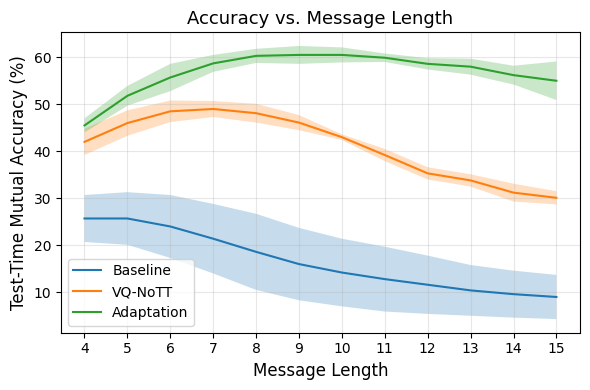

In [53]:
plot(baseline, VQ_NoTT, adapt)

# ImageNet

## Baseline

In [54]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "message_length": "[2, 3, 4]"
}, sort_by=["message_length", "seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,0.859,20251231_1826_bs32_vocab10_repr2048_msg_len4_l...
1,2,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,0.846,20251231_1934_bs32_vocab10_repr2048_msg_len4_l...
2,3,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,0.869,20251231_1958_bs32_vocab10_repr2048_msg_len4_l...


In [55]:
mean_and_std(res)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,imagenet,"[2, 3, 4]",4,imagenet,-,0.0 ± 0.0,85.8 ± 1.2


## Backbone

In [56]:
add_heading(2, "ImageNet")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "imagenet",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    "message_length": "[2, 3, 4]"
}, sort_by=["message_length","seed", "message_length_tt"])

to_html(res[backbone_cols_report])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,imagenet,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,0.884,0.891,20251231_2027_bs32_vocab10_repr2048_msg_len4_l...
1,2,False,imagenet,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,0.884,0.901,20251231_2046_bs32_vocab10_repr2048_msg_len4_l...


In [57]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,imagenet,"[2, 3, 4]",88.4 ± 0.0,89.6 ± 0.7


## VQ-NoTT

In [58]:
add_heading(3, "Baseline")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": "-",
    "message_length": "[2, 3, 4]"
}, sort_by=["message_length", "message_length_tt", "seed"])

res[baseline_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy,path


In [59]:
# VQ_NoTT = mean_and_std(res)
# VQ_NoTT

## Scaling

In [60]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": 'scaling'
}, sort_by=["message_length_tt", "sampling_temperature_tt", "best_of_n"])


# res[scaling_cols]

## Adaptation

In [61]:
add_heading(3, "Adaptation")
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": ["batch_adaptation"],
    "message_length": "[2, 3, 4]"
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

to_html(res[adapt_cols_report])

res[adapt_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path


In [62]:
# final = extract_maxes(res)
# final[adapt_cols]

In [63]:
adapt = mean_and_std(final)
adapt

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist2,batch_adaptation,49.9 ± 1.5,45.5 ± 1.5
1,mnist1,"[3, 4]",5,mnist2,batch_adaptation,57.6 ± 3.6,51.8 ± 2.1
2,mnist1,"[3, 4]",6,mnist2,batch_adaptation,62.8 ± 3.5,55.7 ± 2.9
3,mnist1,"[3, 4]",7,mnist2,batch_adaptation,66.1 ± 2.5,58.7 ± 1.8
4,mnist1,"[3, 4]",8,mnist2,batch_adaptation,68.5 ± 2.5,60.3 ± 1.5
5,mnist1,"[3, 4]",9,mnist2,batch_adaptation,70.3 ± 2.7,60.5 ± 1.9
6,mnist1,"[3, 4]",10,mnist2,batch_adaptation,71.8 ± 3.0,60.5 ± 1.6
7,mnist1,"[3, 4]",11,mnist2,batch_adaptation,71.3 ± 2.0,59.9 ± 0.9
8,mnist1,"[3, 4]",12,mnist2,batch_adaptation,71.9 ± 2.1,58.6 ± 1.2
9,mnist1,"[3, 4]",13,mnist2,batch_adaptation,72.5 ± 2.2,58.0 ± 1.7


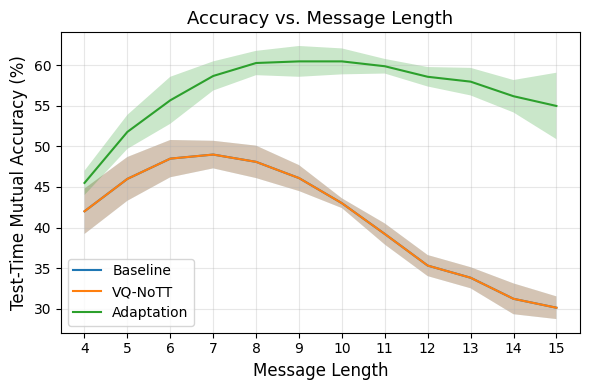

In [64]:
plot(VQ_NoTT, VQ_NoTT, adapt)

# Shape Single Attribute


## Baseline

In [65]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape_unique_atleast_one_attribute",
    "sim": "cosine",
    "baseline": True,
    "dialogued_checkpoint": "None"
}, sort_by=["seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.954,20251230_2218_bs1_vocab10_repr1024_msg_len4_lr...
1,2,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.954,20251230_2227_bs1_vocab10_repr1024_msg_len4_lr...
2,3,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",1e-04,-,1e-04,-,0,0.952,20251230_2237_bs1_vocab10_repr1024_msg_len4_lr...


In [66]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape_unique_atleast_one_attribute",
    "sim": "cosine",
    "baseline": True,
    "dialogued_checkpoint": "!None"
}, sort_by=["message_length_tt", "seed"])

res[baseline_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,-,0,0.838,20251230_2251_bs1_vocab10_repr1024_msg_len4_lr...
1,2,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,-,0,0.865,20251230_2253_bs1_vocab10_repr1024_msg_len4_lr...
2,3,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,-,0,0.86,20251230_2255_bs1_vocab10_repr1024_msg_len4_lr...
3,1,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",5,dual_attribute_shape,-,0,0.857,20251230_2251_bs1_vocab10_repr1024_msg_len5_lr...
4,2,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",5,dual_attribute_shape,-,0,0.876,20251230_2253_bs1_vocab10_repr1024_msg_len5_lr...
5,3,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",5,dual_attribute_shape,-,0,0.887,20251230_2255_bs1_vocab10_repr1024_msg_len5_lr...
6,1,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",6,dual_attribute_shape,-,0,0.848,20251230_2251_bs1_vocab10_repr1024_msg_len6_lr...
7,2,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",6,dual_attribute_shape,-,0,0.805,20251230_2253_bs1_vocab10_repr1024_msg_len6_lr...
8,3,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",6,dual_attribute_shape,-,0,0.873,20251230_2255_bs1_vocab10_repr1024_msg_len6_lr...
9,1,True,shape_unique_atleast_one_attribute,cosine,"[3, 4]",7,dual_attribute_shape,-,0,0.81,20251230_2251_bs1_vocab10_repr1024_msg_len7_lr...


In [67]:
baseline = mean_and_std(res)
baseline

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape_unique_atleast_one_attribute,"[3, 4]",4,dual_attribute_shape,-,0.0 ± 0.0,85.4 ± 1.4
1,shape_unique_atleast_one_attribute,"[3, 4]",5,dual_attribute_shape,-,0.0 ± 0.0,87.3 ± 1.5
2,shape_unique_atleast_one_attribute,"[3, 4]",6,dual_attribute_shape,-,0.0 ± 0.0,84.2 ± 3.4
3,shape_unique_atleast_one_attribute,"[3, 4]",7,dual_attribute_shape,-,0.0 ± 0.0,78.9 ± 6.5
4,shape_unique_atleast_one_attribute,"[3, 4]",8,dual_attribute_shape,-,0.0 ± 0.0,70.7 ± 11.4
5,shape_unique_atleast_one_attribute,"[3, 4]",9,dual_attribute_shape,-,0.0 ± 0.0,62.3 ± 12.5
6,shape_unique_atleast_one_attribute,"[3, 4]",10,dual_attribute_shape,-,0.0 ± 0.0,55.0 ± 12.7
7,shape_unique_atleast_one_attribute,"[3, 4]",11,dual_attribute_shape,-,0.0 ± 0.0,48.6 ± 13.1
8,shape_unique_atleast_one_attribute,"[3, 4]",12,dual_attribute_shape,-,0.0 ± 0.0,42.0 ± 13.1
9,shape_unique_atleast_one_attribute,"[3, 4]",13,dual_attribute_shape,-,0.0 ± 0.0,37.6 ± 12.1


## Backbone

In [68]:
add_heading(2, "Single Attribute  Shape")
add_heading(3, "Base Model")
res = filter_df({
    "dataset": "shape_unique_atleast_one_attribute",
    "sim": "cosine",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-",
    "pretrained_checkpoint_a": "None"
}, sort_by=["seed", "message_length", "message_length_tt"])

to_html(res[backbone_cols_report])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",1e-04,-,1e-04,-,0.944,0.938,20251226_1853_bs1_vocab10_repr1024_lr1_0.0001_...
1,2,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",1e-04,-,1e-04,-,0.946,0.941,20251228_1757_bs1_vocab10_repr1024_msg_len2_lr...
2,3,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",1e-04,-,1e-04,-,0.939,0.94,20251228_1818_bs1_vocab10_repr1024_msg_len2_lr...


In [69]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,shape_unique_atleast_one_attribute,"[3, 4]",94.3 ± 0.4,94.0 ± 0.2


## VQ-NoTT

In [70]:
add_heading(3, "Baseline")
res = filter_df({
    "dataset": "shape_unique_atleast_one_attribute",
    "baseline": False,
    "test_time_mode": "-",
    "message_length": "[3, 4]",
    "pretrained_checkpoint_a": "!None"
}, sort_by=["message_length", "message_length_tt", "seed"])

to_html(res[baseline_cols_report])

res[baseline_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,-,0.797,0.798,20251226_2121_bs1_vocab10_repr1024_lr1_0.0001_...
1,2,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,-,0.815,0.811,20251229_0747_bs1_vocab10_repr1024_msg_len4_lr...
2,3,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,-,0.794,0.813,20251229_0749_bs1_vocab10_repr1024_msg_len4_lr...
3,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",5,dual_attribute_shape,-,0.848,0.832,20251226_2120_bs1_vocab10_repr1024_lr1_0.0001_...
4,2,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",5,dual_attribute_shape,-,0.867,0.857,20251229_0747_bs1_vocab10_repr1024_msg_len5_lr...
5,3,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",5,dual_attribute_shape,-,0.841,0.855,20251229_0750_bs1_vocab10_repr1024_msg_len5_lr...
6,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",6,dual_attribute_shape,-,0.824,0.817,20251226_2122_bs1_vocab10_repr1024_lr1_0.0001_...
7,2,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",6,dual_attribute_shape,-,0.831,0.834,20251229_0747_bs1_vocab10_repr1024_msg_len6_lr...
8,3,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",6,dual_attribute_shape,-,0.832,0.85,20251229_0750_bs1_vocab10_repr1024_msg_len6_lr...
9,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",7,dual_attribute_shape,-,0.663,0.769,20251226_2145_bs1_vocab10_repr1024_lr1_0.0001_...


In [71]:
VQ_NoTT = mean_and_std(res)
VQ_NoTT

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,shape_unique_atleast_one_attribute,"[3, 4]",4,dual_attribute_shape,-,80.2 ± 1.1,80.7 ± 0.8
1,shape_unique_atleast_one_attribute,"[3, 4]",5,dual_attribute_shape,-,85.2 ± 1.3,84.8 ± 1.4
2,shape_unique_atleast_one_attribute,"[3, 4]",6,dual_attribute_shape,-,82.9 ± 0.4,83.4 ± 1.7
3,shape_unique_atleast_one_attribute,"[3, 4]",7,dual_attribute_shape,-,69.6 ± 3.3,78.5 ± 1.8
4,shape_unique_atleast_one_attribute,"[3, 4]",8,dual_attribute_shape,-,40.3 ± 9.3,71.4 ± 2.0
5,shape_unique_atleast_one_attribute,"[3, 4]",9,dual_attribute_shape,-,12.4 ± 6.9,62.6 ± 2.4
6,shape_unique_atleast_one_attribute,"[3, 4]",10,dual_attribute_shape,-,3.5 ± 2.0,53.5 ± 2.7
7,shape_unique_atleast_one_attribute,"[3, 4]",11,dual_attribute_shape,-,3.3 ± 1.5,45.7 ± 2.7
8,shape_unique_atleast_one_attribute,"[3, 4]",12,dual_attribute_shape,-,3.7 ± 1.7,38.4 ± 3.2
9,shape_unique_atleast_one_attribute,"[3, 4]",13,dual_attribute_shape,-,4.0 ± 1.9,32.3 ± 2.9


## Scaling

In [72]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "shape_unique_atleast_one_attribute",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": 'scaling'
}, sort_by=["message_length_tt", "sampling_temperature_tt", "best_of_n"])

to_html(res[scaling_cols_report])

# res[scaling_cols]

## Adaptation

In [73]:
add_heading(3, "Adaptation")
res = filter_df({
    "dataset": "shape_unique_atleast_one_attribute",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": ["batch_adaptation", "dataset_adaptation"],
}, sort_by=["message_length", "test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

res[adapt_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,batch_adaptation,1e-04,25,0.798,0.766,20251230_1225_bs1_vocab10_repr1024_msg_len4_lr...
1,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,batch_adaptation,1e-04,50,0.809,0.761,20251230_0925_bs1_vocab10_repr1024_msg_len4_lr...
2,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,batch_adaptation,1e-04,100,0.791,0.708,20251229_2349_bs1_vocab10_repr1024_msg_len4_lr...
3,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,batch_adaptation,1e-05,200,0.824,0.799,20251226_2130_bs1_vocab10_repr1024_lr1_0.0001_...
4,2,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,batch_adaptation,1e-04,25,0.734,0.74,20251230_1232_bs1_vocab10_repr1024_msg_len4_lr...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",15,dual_attribute_shape,batch_adaptation,1e-05,300,0.811,0.52,20251229_0642_bs1_vocab10_repr1024_msg_len15_l...
147,3,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",15,dual_attribute_shape,batch_adaptation,1e-04,25,0.354,0.383,20251230_1246_bs1_vocab10_repr1024_msg_len15_l...
148,3,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",15,dual_attribute_shape,batch_adaptation,1e-04,50,0.513,0.479,20251230_1000_bs1_vocab10_repr1024_msg_len15_l...
149,3,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",15,dual_attribute_shape,batch_adaptation,1e-04,100,0.747,0.433,20251230_0050_bs1_vocab10_repr1024_msg_len15_l...


In [74]:
final = extract_maxes(res)
final[adapt_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,batch_adaptation,1e-05,200,0.824,0.799,20251226_2130_bs1_vocab10_repr1024_lr1_0.0001_...
1,2,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,batch_adaptation,1e-05,300,0.783,0.769,20251229_0551_bs1_vocab10_repr1024_msg_len4_lr...
2,3,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",4,dual_attribute_shape,batch_adaptation,1e-05,300,0.795,0.793,20251229_0648_bs1_vocab10_repr1024_msg_len4_lr...
3,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",5,dual_attribute_shape,batch_adaptation,1e-05,200,0.898,0.875,20251226_2132_bs1_vocab10_repr1024_lr1_0.0001_...
4,2,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",5,dual_attribute_shape,batch_adaptation,1e-05,300,0.871,0.861,20251229_0554_bs1_vocab10_repr1024_msg_len5_lr...
5,3,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",5,dual_attribute_shape,batch_adaptation,1e-05,300,0.898,0.878,20251229_0651_bs1_vocab10_repr1024_msg_len5_lr...
6,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",6,dual_attribute_shape,batch_adaptation,1e-05,300,0.934,0.894,20251226_2152_bs1_vocab10_repr1024_lr1_0.0001_...
7,2,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",6,dual_attribute_shape,batch_adaptation,1e-05,300,0.913,0.871,20251229_0557_bs1_vocab10_repr1024_msg_len6_lr...
8,3,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",6,dual_attribute_shape,batch_adaptation,1e-05,300,0.91,0.877,20251229_0654_bs1_vocab10_repr1024_msg_len6_lr...
9,1,False,shape_unique_atleast_one_attribute,cosine,"[3, 4]",7,dual_attribute_shape,batch_adaptation,1e-05,200,0.843,0.867,20251226_2136_bs1_vocab10_repr1024_lr1_0.0001_...


In [75]:
adapt = mean_and_std(final)
# adapt

In [76]:
import matplotlib.pyplot as plt

def plot(df1, df2, df3, labels=("Baseline", "VQ-NoTT", "Adaptation")):
    plt.figure(figsize=(6, 4))

    for df, label in zip((df1, df2, df3), labels):
        df = df.copy()

        # Split "mean ± std"
        df[["mean_acc", "std_acc"]] = (
            df["test_time_mutual_accuracy"]
            .str.split("±", expand=True)
            .astype(float)
        )
        df = df.sort_values("message_length_tt")

        x = df["message_length_tt"][:6]
        y = df["mean_acc"][:6]
        err = df["std_acc"][:6]

        plt.plot(x, y, label=label)
        plt.fill_between(x, y - err, y + err, alpha=0.25)

    plt.xlabel("Message Length", fontsize=12)
    plt.ylabel("Test-Time Mutual Accuracy (%)", fontsize=12)
    plt.title("Accuracy vs. Message Length", fontsize=13)
    plt.xticks(x)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

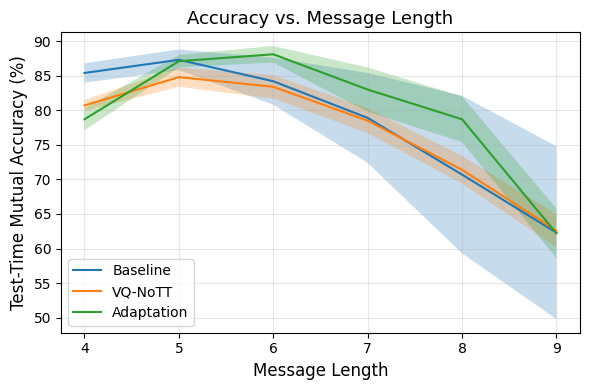

In [77]:
plot(baseline, VQ_NoTT, adapt)